In [1]:
import kagglehub
from os import getcwd
import shutil

In [2]:
path = kagglehub.dataset_download(
    "uciml/zoo-animal-classification")
shutil.copytree(path, getcwd(), dirs_exist_ok=True)

100%|██████████| 1.85k/1.85k [00:00<00:00, 2.68MB/s]

Extracting files...


'/content'

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("zoo.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [6]:
df.isnull().sum()

,0
animal_name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


In [7]:
df.drop(["animal_name"], axis=1, inplace=True)

In [8]:
df.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

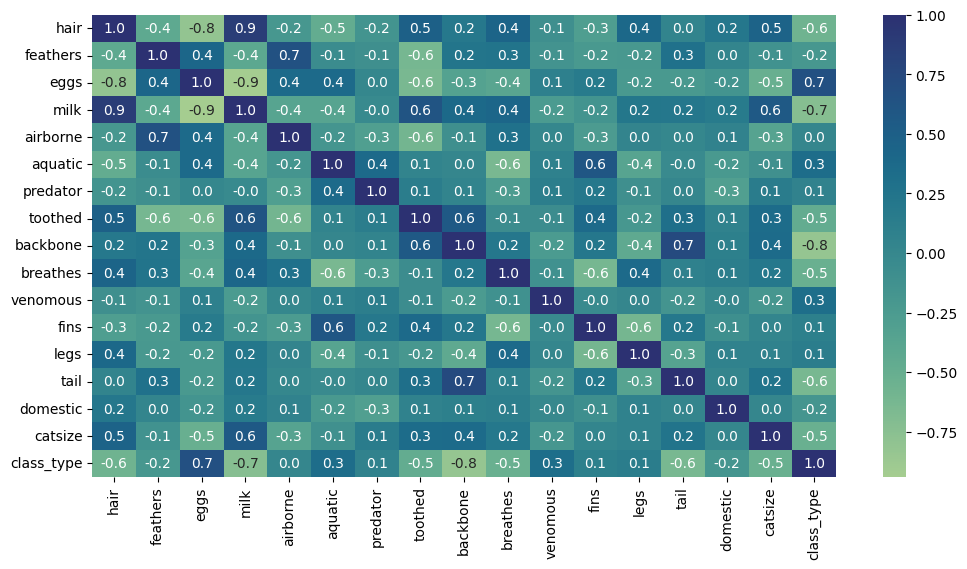

In [10]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt='.1f', cmap='crest')

In [ ]:
target_corr = (
    df.select_dtypes(include="number")
      .corr()["class_type"]
      .drop("class_type")
      .sort_values(key=abs, ascending=False)
)

strong_features = target_corr[target_corr.abs() > 0.5]

In [16]:
df = df[strong_features.index.tolist()
        + ["class_type"]]

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   backbone    101 non-null    int64
 1   milk        101 non-null    int64
 2   eggs        101 non-null    int64
 3   tail        101 non-null    int64
 4   hair        101 non-null    int64
 5   catsize     101 non-null    int64
 6   breathes    101 non-null    int64
 7   class_type  101 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [18]:
df["class_type"].value_counts()

,count
class_type,
1,41
2,20
4,13
7,10
6,8
3,5
5,4


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

In [20]:
x = df.drop(['class_type'], axis='columns')
y = df["class_type"]

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, random_state = 10)

In [21]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [22]:
model.score(x_test, y_test)

0.9047619047619048